# n-dimensional Datasets and `xarray`

## Introduction

`xarray`

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

## Loading an `xarray` DataSet

In this section, we will be using ERA5 reanalysis data, a global climate database created by the ECMWF. [Reanalysis data](https://climate.copernicus.eu/climate-reanalysis) combines billions of historical weather observations (e.g. from satellites, weather balloons, and ground stations), using numerical models to fill in any missing spatial or temporal gaps (it has been described as "maps without gaps"). As a result, it gives researchers an (up to) hourly best estimate of temperature, wind, rainfall, and other atmospheric conditions anywhere on Earth (with caveats surrounding input data and model quality!).

ERA5 data is downloadable from the [ECMWF Climate Data Store](https://cds.climate.copernicus.eu/datasets) - you will need to sign up to download data. In the interests of keeping file sizes small, I have used a very small sample here: [monthly averaged land surface data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-monthly-means?tab=download) for 2 m temperature and total precipiation over Great Britain and Ireland between 2016 and 2025. The full dataset provides hourly data, through the entire atmospheric column, for a countless number of variables over the entire globe back to 1940. 

> If you are interesting in using ERA-5 data within your final reports - and f you have no need to use large-scale gridded data - you can use the [open-meteo historical weather API](https://open-meteo.com/en/docs/historical-weather-api) to view and download (in `csv` format) hourly and monthly data at a single point.

The data can be downloaded [from here](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/04/era5_regional.nc). Note the `.nc` filetype: this is a [NetCDF](https://en.wikipedia.org/wiki/NetCDF) file, probably the most common file format for storing large-scale gridded climate data.

In [3]:
era5_xr = xr.open_dataset("era5_regional.nc")

Let's inspect:

In [4]:
era5_xr

<xarray.Dataset> Size: 14MB
Dimensions:     (valid_time: 120, latitude: 104, longitude: 139)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2016-01-01 ... 2025-12-01
    expver      (valid_time) <U4 2kB ...
  * latitude    (latitude) float64 832B 59.8 59.7 59.6 59.5 ... 49.7 49.6 49.5
  * longitude   (longitude) float64 1kB -10.9 -10.8 -10.7 -10.6 ... 2.7 2.8 2.9
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 7MB ...
    tp          (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-25T15:22 GRIB to CDM+CF via cfgrib-0.9.1...

Note three main dimensions:

In [9]:
era5_xr.valid_time

<xarray.DataArray 'valid_time' (valid_time: 120)> Size: 960B
array(['2016-01-01T00:00:00.000000000', '2016-02-01T00:00:00.000000000',
       '2016-03-01T00:00:00.000000000', '2016-04-01T00:00:00.000000000',
       '2016-05-01T00:00:00.000000000', '2016-06-01T00:00:00.000000000',
       '2016-07-01T00:00:00.000000000', '2016-08-01T00:00:00.000000000',
       '2016-09-01T00:00:00.000000000', '2016-10-01T00:00:00.000000000',
       '2016-11-01T00:00:00.000000000', '2016-12-01T00:00:00.000000000',
       '2017-01-01T00:00:00.000000000', '2017-02-01T00:00:00.000000000',
       '2017-03-01T00:00:00.000000000', '2017-04-01T00:00:00.000000000',
       '2017-05-01T00:00:00.000000000', '2017-06-01T00:00:00.000000000',
       '2017-07-01T00:00:00.000000000', '2017-08-01T00:00:00.000000000',
       '2017-09-01T00:00:00.000000000', '2017-10-01T00:00:00.000000000',
       '2017-11-01T00:00:00.000000000', '2017-12-01T00:00:00.000000000',
       '2018-01-01T00:00:00.000000000', '2018-02-01T00:00:00.000000000',
       '2018-03-01T00:00:00.000000000', '2018-04-01T00:00:00.000000000',
       '2018-05-01T00:00:00.000000000', '2018-06-01T00:00:00.000000000',
       '2018-07-01T00:00:00.000000000', '2018-08-01T00:00:00.000000000',
       '2018-09-01T00:00:00.000000000', '2018-10-01T00:00:00.000000000',
       '2018-11-01T00:00:00.000000000', '2018-12-01T00:00:00.000000000',
       '2019-01-01T00:00:00.000000000', '2019-02-01T00:00:00.000000000',
       '2019-03-01T00:00:00.000000000', '2019-04-01T00:00:00.000000000',
       '2019-05-01T00:00:00.000000000', '2019-06-01T00:00:00.000000000',
       '2019-07-01T00:00:00.000000000', '2019-08-01T00:00:00.000000000',
       '2019-09-01T00:00:00.000000000', '2019-10-01T00:00:00.000000000',
       '2019-11-01T00:00:00.000000000', '2019-12-01T00:00:00.000000000',
       '2020-01-01T00:00:00.000000000', '2020-02-01T00:00:00.000000000',
       '2020-03-01T00:00:00.000000000', '2020-04-01T00:00:00.000000000',
       '2020-05-01T00:00:00.000000000', '2020-06-01T00:00:00.000000000',
       '2020-07-01T00:00:00.000000000', '2020-08-01T00:00:00.000000000',
       '2020-09-01T00:00:00.000000000', '2020-10-01T00:00:00.000000000',
       '2020-11-01T00:00:00.000000000', '2020-12-01T00:00:00.000000000',
       '2021-01-01T00:00:00.000000000', '2021-02-01T00:00:00.000000000',
       '2021-03-01T00:00:00.000000000', '2021-04-01T00:00:00.000000000',
       '2021-05-01T00:00:00.000000000', '2021-06-01T00:00:00.000000000',
       '2021-07-01T00:00:00.000000000', '2021-08-01T00:00:00.000000000',
       '2021-09-01T00:00:00.000000000', '2021-10-01T00:00:00.000000000',
       '2021-11-01T00:00:00.000000000', '2021-12-01T00:00:00.000000000',
       '2022-01-01T00:00:00.000000000', '2022-02-01T00:00:00.000000000',
       '2022-03-01T00:00:00.000000000', '2022-04-01T00:00:00.000000000',
       '2022-05-01T00:00:00.000000000', '2022-06-01T00:00:00.000000000',
       '2022-07-01T00:00:00.000000000', '2022-08-01T00:00:00.000000000',
       '2022-09-01T00:00:00.000000000', '2022-10-01T00:00:00.000000000',
       '2022-11-01T00:00:00.000000000', '2022-12-01T00:00:00.000000000',
       '2023-01-01T00:00:00.000000000', '2023-02-01T00:00:00.000000000',
       '2023-03-01T00:00:00.000000000', '2023-04-01T00:00:00.000000000',
       '2023-05-01T00:00:00.000000000', '2023-06-01T00:00:00.000000000',
       '2023-07-01T00:00:00.000000000', '2023-08-01T00:00:00.000000000',
       '2023-09-01T00:00:00.000000000', '2023-10-01T00:00:00.000000000',
       '2023-11-01T00:00:00.000000000', '2023-12-01T00:00:00.000000000',
       '2024-01-01T00:00:00.000000000', '2024-02-01T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000',
       '2024-07-01T00:00:00.000000000', '2024-08-01T00:00:00.000000000',
       '2024-09-01T00:00:00.000000000', '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000

In [10]:
era5_xr.latitude

<xarray.DataArray 'latitude' (latitude: 104)> Size: 832B
array([59.8, 59.7, 59.6, 59.5, 59.4, 59.3, 59.2, 59.1, 59. , 58.9, 58.8, 58.7,
       58.6, 58.5, 58.4, 58.3, 58.2, 58.1, 58. , 57.9, 57.8, 57.7, 57.6, 57.5,
       57.4, 57.3, 57.2, 57.1, 57. , 56.9, 56.8, 56.7, 56.6, 56.5, 56.4, 56.3,
       56.2, 56.1, 56. , 55.9, 55.8, 55.7, 55.6, 55.5, 55.4, 55.3, 55.2, 55.1,
       55. , 54.9, 54.8, 54.7, 54.6, 54.5, 54.4, 54.3, 54.2, 54.1, 54. , 53.9,
       53.8, 53.7, 53.6, 53.5, 53.4, 53.3, 53.2, 53.1, 53. , 52.9, 52.8, 52.7,
       52.6, 52.5, 52.4, 52.3, 52.2, 52.1, 52. , 51.9, 51.8, 51.7, 51.6, 51.5,
       51.4, 51.3, 51.2, 51.1, 51. , 50.9, 50.8, 50.7, 50.6, 50.5, 50.4, 50.3,
       50.2, 50.1, 50. , 49.9, 49.8, 49.7, 49.6, 49.5])
Coordinates:
  * latitude  (latitude) float64 832B 59.8 59.7 59.6 59.5 ... 49.7 49.6 49.5
    number    int64 8B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

Two options for variables: `t2m` (2 metre temperature) and `tp` (total preciptation)

In [ ]:
era5_xr.t2m

<xarray.DataArray 't2m' (valid_time: 120, latitude: 104, longitude: 139)> Size: 7MB
[1734720 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2016-01-01 ... 2025-12-01
    expver      (valid_time) <U4 2kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 832B 59.8 59.7 59.6 59.5 ... 49.7 49.6 49.5
  * longitude   (longitude) float64 1kB -10.9 -10.8 -10.7 -10.6 ... 2.7 2.8 2.9
    number      int64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      14456
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

Let's inspect the shape:

In [11]:
era5_xr.t2m.shape

(120, 104, 139)

We have, effectively, a 3-D array. 120 length is time, 104 length is latitude, and 139 length is longitude.

We can't visualise a full datacube like this: we are going to have to extract data in some way.

In [19]:
temp_day_slice = era5_xr.t2m.isel(valid_time=0)

temp_day_slice

<xarray.DataArray 't2m' (latitude: 104, longitude: 139)> Size: 58kB
[14456 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 832B 59.8 59.7 59.6 59.5 ... 49.7 49.6 49.5
  * longitude   (longitude) float64 1kB -10.9 -10.8 -10.7 -10.6 ... 2.7 2.8 2.9
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2016-01-01
    expver      <U4 16B '0001'
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      14456
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

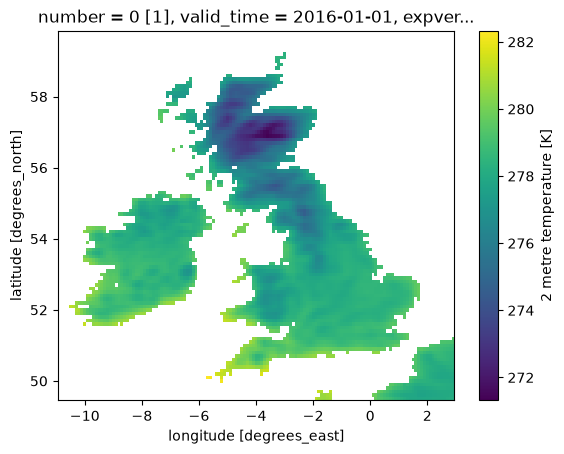

In [21]:
temp_day_slice.plot.imshow()

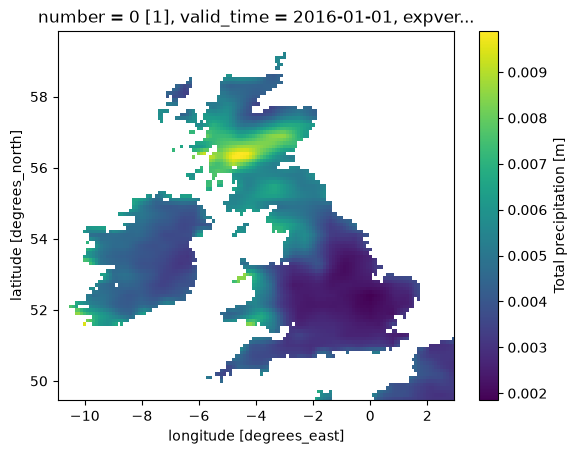

In [22]:
precip_day_slice = era5_xr.tp.isel(valid_time=0)

precip_day_slice.plot.imshow()

We can begin to abstract and aggregate this data

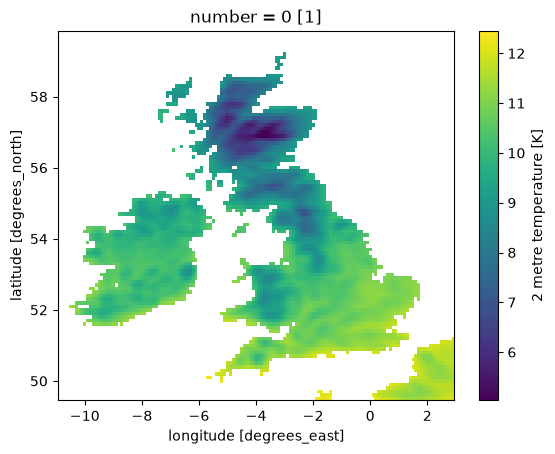

In [24]:
# average temp through period
average_temp = era5_xr.t2m.mean(dim="valid_time")

# convert to celsius
average_temp = average_temp - 273.15

average_temp.plot.imshow()

## Slicing

We're more interested in Bristol?

We can 'slice' the data a different way. Find closest coordinate to bristol:

In [35]:
# temperature and precipitation time series closest to Bristol, -2.60, 51.46
bristol_temp = era5_xr.t2m.sel(latitude=51.46, longitude=-2.60, method="nearest")
bristol_precip = era5_xr.tp.sel(latitude=51.46, longitude=-2.60, method="nearest")

# convert to celsius
bristol_temp = bristol_temp - 273.15

In [36]:
bristol_temp

<xarray.DataArray 't2m' (valid_time: 120)> Size: 480B
array([ 5.8365784,  4.9754944,  5.722809 ,  7.3489075, 12.691315 ,
       15.441925 , 16.84903  , 17.189606 , 16.040192 , 10.802765 ,
        6.369049 ,  6.676544 ,  4.379547 ,  6.3106995,  8.624298 ,
        9.03775  , 13.369171 , 16.235504 , 17.024078 , 15.767731 ,
       13.76004  , 12.717682 ,  7.426422 ,  5.305084 ,  5.726471 ,
        2.9891663,  4.8927307,  9.7274475, 13.435577 , 16.85672  ,
       19.945465 , 16.899078 , 14.1354065, 10.849274 ,  8.579498 ,
        7.9305725,  4.0499573,  6.7502747,  8.100739 ,  9.480499 ,
       11.728668 , 14.415192 , 18.107574 , 16.973297 , 14.795074 ,
       10.791901 ,  6.9881897,  6.4737854,  6.5502014,  6.83902  ,
        6.5067444, 10.808746 , 13.289703 , 15.406525 , 16.021637 ,
       17.879547 , 14.457184 , 10.709381 ,  9.0416565,  5.6598206,
        3.806549 ,  5.5123596,  7.0785217,  6.9562073, 10.379425 ,
       15.810944 , 17.867462 , 15.868439 , 15.987335 , 12.474274 ,
        7.7723694,  7.325836 ,  4.704132 ,  7.3802795,  7.848175 ,
        9.187164 , 12.907135 , 15.122711 , 18.76529  , 19.26529  ,
       14.6180725, 13.38028  ,  9.538239 ,  4.3385315,  4.9774475,
        6.020172 ,  7.311676 ,  8.638214 , 12.889069 , 17.43277  ,
       15.969147 , 16.333405 , 17.045319 , 12.65567  ,  7.9425354,
        7.6688538,  4.8470764,  8.049469 ,  7.8734436,  9.563385 ,
       13.419342 , 14.480255 , 16.41446  , 17.0961   , 14.08902  ,
       11.99527  ,  8.330475 ,  7.488678 ,  3.7762756,  5.5194397,
        7.3508606, 10.791779 , 14.07901  , 16.804352 , 18.916168 ,
       18.038727 , 13.873688 , 11.872711 ,  8.907379 ,  7.1114807],
      dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2016-01-01 ... 2025-12-01
    expver      (valid_time) <U4 2kB '0001' '0001' '0001' ... '0001' '0001'
    number      int64 8B 0
    latitude    float64 8B 51.5
    longitude   float64 8B -2.6
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      14456
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

Note now only one dimension!

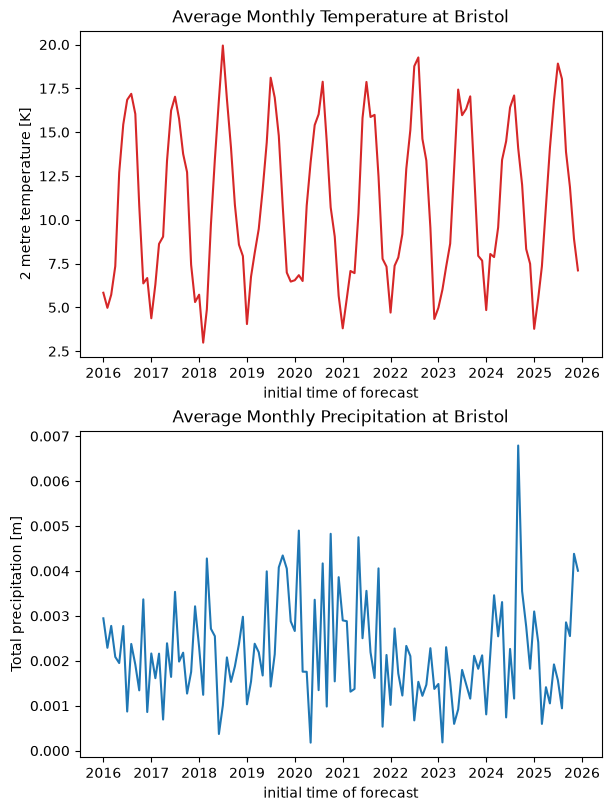

In [37]:
fig, axes = plt.subplots(nrows=2, figsize=(6, 8), constrained_layout=True)

ax = axes[0]
bristol_temp.plot(ax=ax, color="tab:red")
ax.set_title("Average Monthly Temperature at Bristol")

ax = axes[1]
bristol_precip.plot(ax=ax)
ax.set_title("Average Monthly Precipitation at Bristol")

plt.show()

As with `pandas`, we can perform temporal averaging

Text(0.5, 1.0, 'One-Year Running Mean of Average Monthly Temperature at Bristol')

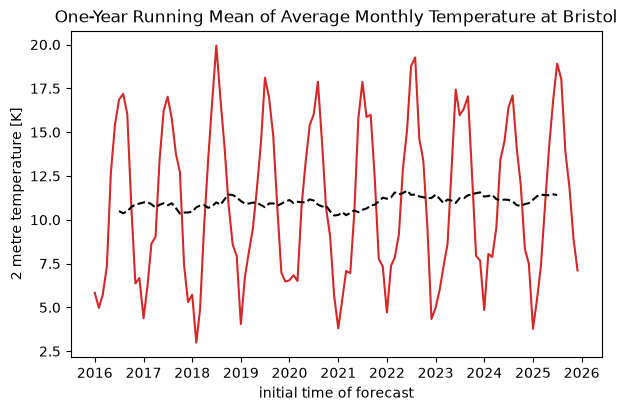

In [ ]:
# one-year running means of the temperature data
bristol_temp_1y = bristol_temp.rolling(valid_time=12, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
bristol_temp.plot(ax=ax, color="tab:red")
bristol_temp_1y.plot(ax=ax, color="k", ls="--")
ax.set_title("One-Year Running Mean of Average Monthly Temperature at Bristol")

Or work out distances at different time. See if you can follow the logic here as we select only the dates when the month is either June, July, or August (the common climatological shorthand for summer in the Northern hemisphere) or December, January, February (climatological winter in the Northern hemisphere). The syntax will bear strong similarities to what we have seen before in Pandas:

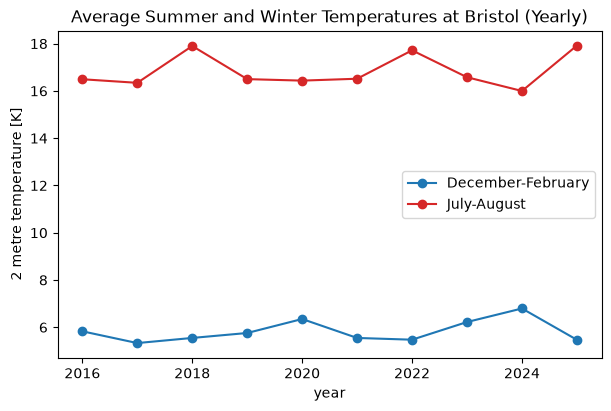

In [45]:
# Calculate JJA (June, July, August) average temperature for each year
jja_temp = bristol_temp.sel(
    valid_time=bristol_temp.valid_time.dt.month.isin([6, 7, 8])
    )
jja_temp_yearly = jja_temp.groupby("valid_time.year").mean()

# Calculate DJF (December, January, February) average temperature for each year
djf_temp = bristol_temp.sel(
    valid_time=bristol_temp.valid_time.dt.month.isin([12, 1, 2])
    )
djf_temp_yearly = djf_temp.groupby("valid_time.year").mean()

# Plot the data
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

djf_temp_yearly.plot(ax=ax, color="tab:blue", marker="o", label="December-February")
jja_temp_yearly.plot(ax=ax, color="tab:red", marker="o", label="July-August")

ax.legend()
ax.set_title("Average Summer and Winter Temperatures at Bristol (Yearly)")

plt.show()